## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 1000)

## 2. Data Loading & Cleaning

In [47]:
df = pd.read_csv('data/clean/final_featuresv2.csv')
df.sort_values(by="date")
exclude_cols = [
    'state', 'date', 'inpatient_beds', 'inpatient_beds_used',
    'inpatient_beds_utilization', 'inpatient_beds_utilization_coverage', "hospital_inpatient_beds", "coverage_per_state",
]
columns_of_interest = [c for c in df.columns if c not in exclude_cols]

df = df[columns_of_interest].dropna().copy()
df

,previous_day_admission_adult_covid_suspected_80_,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,icu_patients_confirmed_influenza,hospital_covid_deaths,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds_used,hospital_patients_hospitalized_confirmed_influenza_and_covid,previous_day_admission_adult_covid_confirmed_normalized,previous_day_admission_adult_covid_suspected_normalized,previous_day_admission_pediatric_covid_confirmed_normalized,previous_day_admission_pediatric_covid_suspected_normalized,inpatient_beds_utilization_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,previous_day_deaths_influenza_normalized,previous_day_admission_pediatric_covid_confirmed_0_4_normalized,previous_day_admission_pediatric_covid_confirmed_12_17_normalized,previous_day_admission_pediatric_covid_confirmed_5_11_normalized,previous_day_admission_pediatric_covid_confirmed_unknown_normalized
36260,36.0,2750.0,2705.0,3422.0,636.0,18.0,847.0,4.0,0.515789,0.083799,0.868932,0.100559,0.868932,112.014563,0.059880,4.752427,1.417910,0.149254,0.154229,0.003607,0.058824,0.341709,0.440000,0.386935,0.701493,0.855000,0.914141,0.885000,0.329949,0.010050,0.082474,0.128205,0.112821,0.149485,0.235897,0.276923,0.185567,0.291667,0.011236,0.0,0.0,0.000000,0.000000,0.0,0.666667
36299,0.0,499.0,150.0,655.0,43.0,0.0,67.0,2.0,0.000000,0.043478,0.958333,0.086957,0.958333,51.458333,0.000000,0.500000,0.000000,0.000000,0.000000,0.032776,0.000000,0.000000,0.130435,0.043478,0.000000,0.086957,0.086957,0.173913,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000
36314,40.0,2843.0,2342.0,3411.0,698.0,18.0,1071.0,2.0,0.453039,0.089385,0.868932,0.123596,0.864078,109.427184,0.054422,4.441748,1.522388,0.154229,0.134328,0.003518,0.029851,0.263959,0.392857,0.408163,0.666667,0.862944,0.843434,0.863636,0.291262,0.010050,0.119171,0.125000,0.109375,0.166667,0.295337,0.248705,0.207254,0.293532,0.011494,0.0,0.0,0.000000,0.000000,0.0,0.800000
36324,35.0,2107.0,404.0,751.0,817.0,0.0,286.0,7.0,0.277778,0.318966,0.822695,0.370690,0.822695,101.056738,0.087719,2.553191,1.087591,0.131387,0.182482,0.005824,0.036765,0.200000,0.189781,0.362963,0.485507,0.540146,0.401460,0.397059,0.021277,0.022556,0.090909,0.090909,0.099237,0.137405,0.282443,0.145038,0.265152,0.000000,0.030534,0.0,0.0,0.000000,0.000000,0.0,1.250000
36325,2.0,774.0,4

## 3. Random Forest — Predicting `inpatient_beds_used`

In [48]:
SEED = 42

X = df.drop(columns='hospital_inpatient_beds_used')
y = df['hospital_inpatient_beds_used']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

boundary = round(len(X) * .3)

X_test = X.iloc[:boundary]
y_test = y.iloc[:boundary]
X_train = X.iloc[boundary:]
y_train = y.iloc[boundary:]

# rfr = RandomForestRegressor(random_state=SEED)
# rfr.fit(X_train, y_train)

### 3.1 Train vs Test R² (Overfitting Check)

In [4]:
r2_train = r2_score(y_train, rfr.predict(X_train))
r2_test  = r2_score(y_test,  rfr.predict(X_test))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Gap:      {r2_train - r2_test:.4f}  (>0.05 suggests overfitting)")

Train R²: 0.9984
Test  R²: 0.5353
Gap:      0.4632  (>0.05 suggests overfitting)


### 3.2 Cross-Validated R²

In [22]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rfr, X, y, cv=tscv, scoring='r2')

print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

KeyboardInterrupt: 

### 3.3 Feature Importances

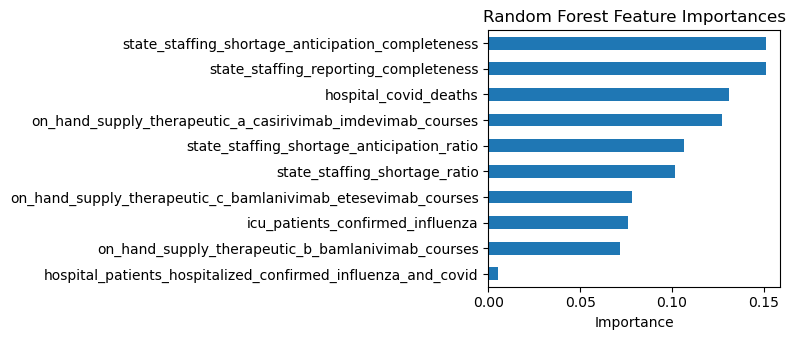

In [59]:
importances = pd.Series(rfr.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, len(importances) * 0.35))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()